# STEP 4. 평가 (Evaluation)
RAGAS 지표(RAG 조건) + ROUGE-L / 키워드 일치율(전체 조건) → 결과 시각화

In [1]:
# [셀1] 결과 로드
import json
from pathlib import Path

RESULT_PATH = Path(r'D:\충북대\지능화캡스톤\data\experiment_results.json')
EVAL_PATH   = Path(r'D:\충북대\지능화캡스톤\data\eval_results.json')

with open(RESULT_PATH, encoding='utf-8') as f:
    all_results = json.load(f)

print(f'총 레코드: {len(all_results)}개')
print('컬럼:', list(all_results[0].keys()))


총 레코드: 498개
컬럼: ['id', 'model', 'condition', 'disaster_type', 'q_type', 'question', 'gold_answer', 'pred_answer', 'context', 'elapsed_sec']


In [2]:
# [셀2] ROUGE-L 계산 (전체 6개 조건 공통 지표)
# pip install rouge-score --quiet
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

def rouge_l(pred: str, gold: str) -> float:
    s = scorer.score(gold, pred)
    return round(s['rougeL'].fmeasure, 4)

# 전체 적용
for r in all_results:
    r['rouge_l'] = rouge_l(r['pred_answer'], r['gold_answer'])

# 모델 × 조건별 평균
from collections import defaultdict
agg = defaultdict(list)
for r in all_results:
    agg[(r['model'], r['condition'])].append(r['rouge_l'])

print('ROUGE-L 평균 (모델 × 조건):')
for (model, cond), vals in sorted(agg.items()):
    print(f'  {model:10s} / {cond:6s}: {sum(vals)/len(vals):.4f}')

ROUGE-L 평균 (모델 × 조건):
  exaone     / no_rag: 0.1141
  exaone     / rag   : 0.1891
  llama31    / no_rag: 0.0654
  llama31    / rag   : 0.1423
  qwen3      / no_rag: 0.0806
  qwen3      / rag   : 0.1698


In [3]:
# [셀3] 키워드 일치율 (hallucination 보조 지표)
import re

def keyword_recall(pred: str, gold: str) -> float:
    '''
    gold_answer의 핵심 명사/숫자 토큰 중
    pred_answer에 등장하는 비율 → 높을수록 ground-truth 반영도 높음
    '''
    # 2글자 이상 한글 단어 + 숫자 추출
    tokens = re.findall(r'[가-힣]{2,}|\d+', gold)
    if not tokens:
        return 0.0
    hit = sum(1 for t in tokens if t in pred)
    return round(hit / len(tokens), 4)

for r in all_results:
    r['kw_recall'] = keyword_recall(r['pred_answer'], r['gold_answer'])

agg_kw = defaultdict(list)
for r in all_results:
    agg_kw[(r['model'], r['condition'])].append(r['kw_recall'])

print('키워드 일치율 평균:')
for (model, cond), vals in sorted(agg_kw.items()):
    print(f'  {model:10s} / {cond:6s}: {sum(vals)/len(vals):.4f}')


키워드 일치율 평균:
  exaone     / no_rag: 0.3136
  exaone     / rag   : 0.5606
  llama31    / no_rag: 0.2461
  llama31    / rag   : 0.4454
  qwen3      / no_rag: 0.2597
  qwen3      / rag   : 0.4684


In [4]:
# [셀4] RAGAS 평가 — RAG 조건만 (faithfulness, answer_relevancy,
#        context_precision, context_recall)
# 필요 패키지: pip install ragas datasets
from ragas import evaluate
from ragas import RunConfig
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_ollama import OllamaLLM, OllamaEmbeddings
from datasets import Dataset

# RAGAS용 LLM/임베딩 설정 (EXAONE 사용)
ragas_llm = LangchainLLMWrapper(
    OllamaLLM(model='exaone3.5:7.8b', temperature=0, num_ctx=4096)
)
ragas_emb = LangchainEmbeddingsWrapper(
    OllamaEmbeddings(model='exaone3.5:7.8b')
)

metrics = [faithfulness, answer_relevancy, context_precision, context_recall]
for m in metrics:
    m.llm = ragas_llm
    if hasattr(m, 'embeddings'):
        m.embeddings = ragas_emb

ragas_scores = {}  # {model_name: score_dict}

for model_name in ['exaone', 'qwen3', 'llama31']:
    rag_records = [
        r for r in all_results
        if r['model'] == model_name and r['condition'] == 'rag'
        and r['context'].strip()  # 컨텍스트가 있는 것만
    ]
    print(f'\n[{model_name}] RAGAS 평가 중... ({len(rag_records)}개)')

    data = {
        'question':     [r['question']     for r in rag_records],
        'answer':       [r['pred_answer']  for r in rag_records],
        'contexts':     [[r['context']]    for r in rag_records],
        'ground_truth': [r['gold_answer']  for r in rag_records],
    }
    dataset = Dataset.from_dict(data)

    try:
        result = evaluate(
            dataset,
            metrics=metrics,
            run_config=RunConfig(
                timeout=180,      # 초 단위 (기본값이 너무 짧음)
                max_workers=1,    # 병렬 처리 끄기 → 순차 실행
                max_retries=2,
            )
        )
        ragas_scores[model_name] = {
            'faithfulness':      round(result['faithfulness'], 4),
            'answer_relevancy':  round(result['answer_relevancy'], 4),
            'context_precision': round(result['context_precision'], 4),
            'context_recall':    round(result['context_recall'], 4),
        }
        print(f'  → {ragas_scores[model_name]}')
    except Exception as e:
        print(f'  [ERROR] {e}')
        ragas_scores[model_name] = {}

print('\nRagas 평가 완료')

d:\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\hyebi\AppData\Local\Temp\ipykernel_27340\1590172711.py:6: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
C:\Users\hyebi\AppData\Local\Temp\ipykernel_27340\1590172711.py:6: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
C:\Users\hyebi\AppData\Local\Temp\ipykernel_27340\1590172711.py:6: DeprecationWarning: Importing context_precision from 'ragas.metrics


[exaone] RAGAS 평가 중... (83개)


Evaluating:  50%|█████     | 167/332 [18:12<18:36,  6.77s/it]ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt context_recall_classification_prompt failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.executor:Exception raised in Job[167]: RagasOutputParserException(The output parser failed to parse the output including retries.)
Evaluating: 100%|██████████| 332/332 [36:50<00:00,  6.66s/it]


  [ERROR] type list doesn't define __round__ method

[qwen3] RAGAS 평가 중... (83개)


Evaluating:  50%|█████     | 167/332 [17:01<13:55,  5.06s/it]ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt context_recall_classification_prompt failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.executor:Exception raised in Job[167]: RagasOutputParserException(The output parser failed to parse the output including retries.)
Evaluating:  89%|████████▉ | 296/332 [30:23<03:23,  5.65s/it]ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the ou

  [ERROR] type list doesn't define __round__ method

[llama31] RAGAS 평가 중... (83개)


Evaluating:  50%|█████     | 167/332 [15:54<14:04,  5.12s/it]ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt context_recall_classification_prompt failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.executor:Exception raised in Job[167]: RagasOutputParserException(The output parser failed to parse the output including retries.)
Evaluating:  98%|█████████▊| 324/332 [32:15<01:04,  8.10s/it]ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the ou

  [ERROR] type list doesn't define __round__ method

Ragas 평가 완료


In [5]:
# [셀5] 종합 결과 테이블 생성
import pandas as pd

rows = []
for (model, cond), vals in sorted(agg.items()):
    row = {
        'model':   model,
        'condition': cond,
        'rouge_l': round(sum(vals)/len(vals), 4),
        'kw_recall': round(sum(agg_kw[(model,cond)])/len(agg_kw[(model,cond)]), 4),
    }
    # RAGAS 지표 (RAG 조건만)
    if cond == 'rag' and model in ragas_scores:
        row.update(ragas_scores[model])
    else:
        row.update({'faithfulness': None, 'answer_relevancy': None,
                    'context_precision': None, 'context_recall': None})
    rows.append(row)

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# CSV 저장
csv_path = Path(r'D:\충북대\지능화캡스톤\data\eval_summary.csv')
df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'\nCSV 저장: {csv_path}')


  model condition  rouge_l  kw_recall  faithfulness  answer_relevancy  context_precision  context_recall
 exaone    no_rag   0.1141     0.3136           NaN               NaN                NaN             NaN
 exaone       rag   0.1891     0.5606           NaN               NaN                NaN             NaN
llama31    no_rag   0.0654     0.2461           NaN               NaN                NaN             NaN
llama31       rag   0.1423     0.4454           NaN               NaN                NaN             NaN
  qwen3    no_rag   0.0806     0.2597           NaN               NaN                NaN             NaN
  qwen3       rag   0.1698     0.4684           NaN               NaN                NaN             NaN

CSV 저장: D:\충북대\지능화캡스톤\data\eval_summary.csv


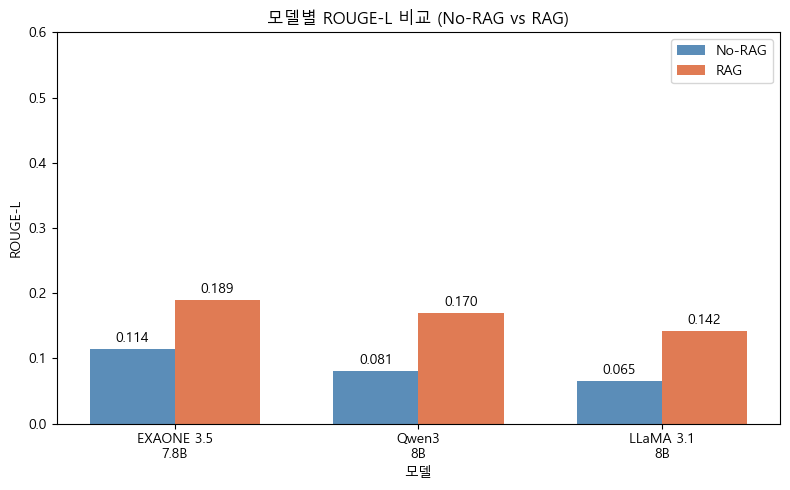

저장: D:\충북대\지능화캡스톤\data\fig_rougeL.png


In [7]:
# [셀6] 시각화 ① 모델 × 조건별 ROUGE-L 막대그래프
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import numpy as np

model_order = ['exaone', 'qwen3', 'llama31']
model_labels = ['EXAONE 3.5\n7.8B', 'Qwen3\n8B', 'LLaMA 3.1\n8B']

no_rag_scores = [sum(agg[(m,'no_rag')])/len(agg[(m,'no_rag')]) for m in model_order]
rag_scores    = [sum(agg[(m,'rag')])/len(agg[(m,'rag')])    for m in model_order]

x = np.arange(len(model_order))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, no_rag_scores, width, label='No-RAG', color='#5B8DB8')
bars2 = ax.bar(x + width/2, rag_scores,    width, label='RAG',    color='#E07B54')

ax.set_xlabel('모델')
ax.set_ylabel('ROUGE-L')
ax.set_title('모델별 ROUGE-L 비교 (No-RAG vs RAG)')
ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.set_ylim(0, 0.6)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()

fig_path = Path(r'D:\충북대\지능화캡스톤\data\fig_rougeL.png')
plt.savefig(fig_path, dpi=150)
plt.show()
print(f'저장: {fig_path}')


C:\Users\hyebi\AppData\Local\Temp\ipykernel_27340\2693935646.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))


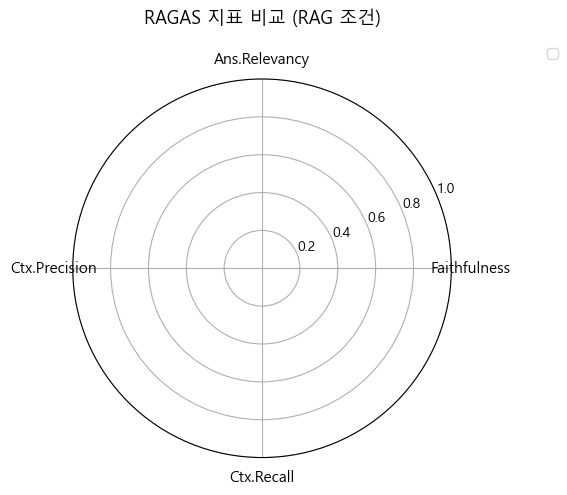

저장: D:\충북대\지능화캡스톤\data\fig_ragas_radar.png


In [8]:
# [셀7] 시각화 ② RAGAS 지표 레이더 차트 (RAG 조건)
import matplotlib.pyplot as plt
import numpy as np

categories = ['Faithfulness', 'Ans.Relevancy', 'Ctx.Precision', 'Ctx.Recall']
keys = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
colors = ['#2ECC71', '#3498DB', '#E74C3C']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for i, model in enumerate(model_order):
    if model not in ragas_scores or not ragas_scores[model]:
        continue
    vals = [ragas_scores[model].get(k, 0) for k in keys]
    vals += vals[:1]
    ax.plot(angles, vals, color=colors[i], linewidth=2,
            label=model_labels[i].replace('\n', ' '))
    ax.fill(angles, vals, color=colors[i], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title('RAGAS 지표 비교 (RAG 조건)', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()

fig_path2 = Path(r'D:\충북대\지능화캡스톤\data\fig_ragas_radar.png')
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {fig_path2}')

In [9]:
# [셀8] 질문 유형별 성능 분석
q_types = ['절차형', '수치법령형', '안전판단형', '복합추론형']

print('질문 유형별 ROUGE-L (exaone, RAG 조건):')
for qt in q_types:
    subset = [r for r in all_results
              if r['q_type'] == qt and r['model'] == 'exaone'
              and r['condition'] == 'rag']
    if subset:
        avg = sum(r['rouge_l'] for r in subset) / len(subset)
        print(f'  {qt:8s}: {avg:.4f}  (n={len(subset)})')

# RAG 향상도 계산 (rag - no_rag)
print('\nRAG 향상도 (ROUGE-L: RAG - No-RAG):')
for model in model_order:
    no = sum(agg[(model,'no_rag')]) / len(agg[(model,'no_rag')])
    ra = sum(agg[(model,'rag')])    / len(agg[(model,'rag')])
    diff = ra - no
    print(f'  {model:10s}: {diff:+.4f}')

질문 유형별 ROUGE-L (exaone, RAG 조건):
  절차형     : 0.0689  (n=30)
  수치법령형   : 0.4045  (n=16)
  안전판단형   : 0.1389  (n=24)
  복합추론형   : 0.2938  (n=13)

RAG 향상도 (ROUGE-L: RAG - No-RAG):
  exaone    : +0.0749
  qwen3     : +0.0893
  llama31   : +0.0769


In [10]:
# [셀9] 최종 결과 저장 (개별 레코드 + RAGAS)
eval_output = {
    'summary_table': rows,
    'ragas_scores': ragas_scores,
    'per_record': all_results,
}
with open(EVAL_PATH, 'w', encoding='utf-8') as f:
    json.dump(eval_output, f, ensure_ascii=False, indent=2)

print(f'평가 결과 저장 완료: {EVAL_PATH}')
print('\n===== 프로젝트 완료 =====')
print('생성 파일:')
print(f'  experiment_results.json ({len(all_results)}개 레코드)')
print(f'  eval_summary.csv')
print(f'  eval_results.json')
print(f'  fig_rougeL.png')
print(f'  fig_ragas_radar.png')

평가 결과 저장 완료: D:\충북대\지능화캡스톤\data\eval_results.json

===== 프로젝트 완료 =====
생성 파일:
  experiment_results.json (498개 레코드)
  eval_summary.csv
  eval_results.json
  fig_rougeL.png
  fig_ragas_radar.png
